Neste notebook, abordaremos a manipulação básica de imagens digitais na prática utilizando Python e a biblioteca OpenCV , com ambiente adaptado para o Google Colab .

O objetivo principal é extrair uma Região de Interesse (ROI - Region of Interest ) de uma imagem, técnica fundamental em Visão Computacional para focar apenas nos elementos relevantes de uma cena antes de aplicar processamentos mais complexos.

Este código em Python utiliza a biblioteca OpenCV para realizar o corte (*crop*) de uma região específica de uma imagem.

Ele carrega uma imagem original (`test.jpg`), exibe suas dimensões na tela e seleciona uma área de interesse delimitando intervalos específicos para as coordenadas de altura e largura (linhas e colunas da matriz de pixels). Em seguida, o trecho recortado é exibido diretamente na interface e salvo como um novo arquivo de imagem (`Cropped Image.jpg`).

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving test.jpg to test (3).jpg


(682, 1024, 3)


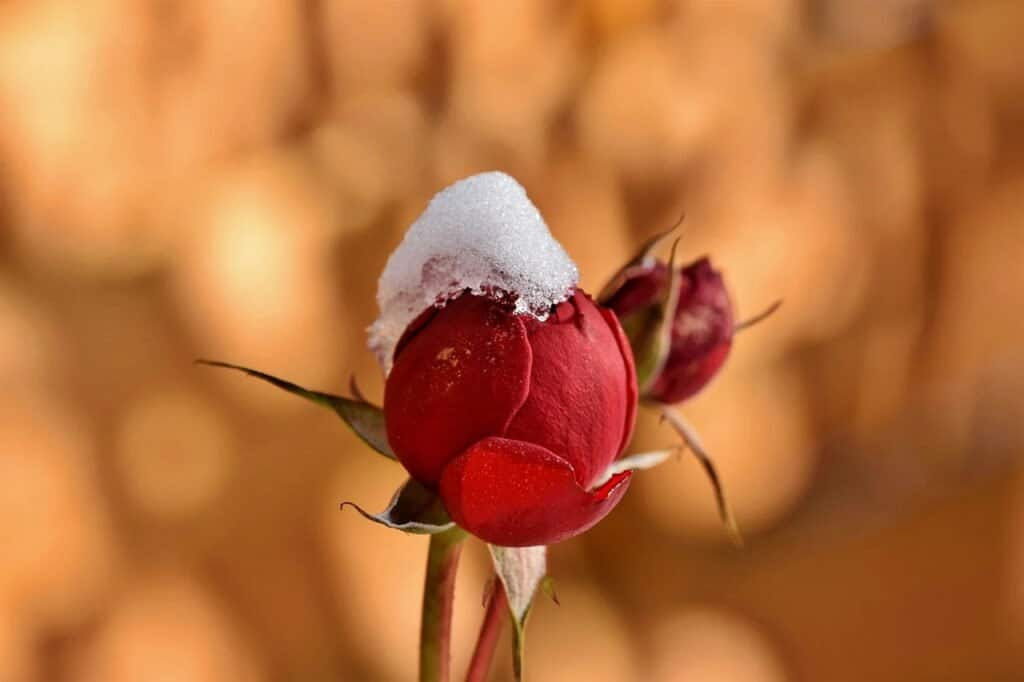

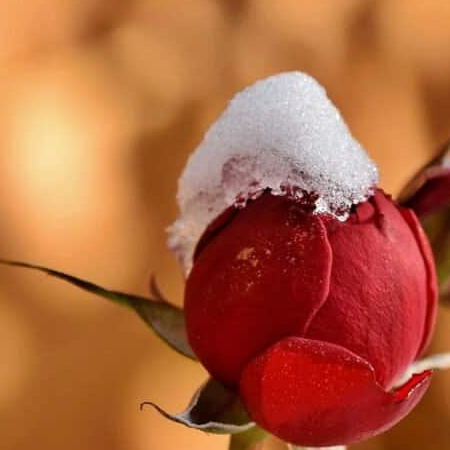

Imagem recortada salva como 'test_cropped.jpg'


In [ ]:
# Import packages
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Read the image
img = cv2.imread('test.jpg')

# Print image shape
print(img.shape)

# Display original image
cv2_imshow(img)

# Cropping an image
cropped_image = img[100:550, 200:650]

# Display cropped image
cv2_imshow(cropped_image)

# Save the cropped image
cv2.imwrite("test_cropped.jpg", cropped_image)

print("Imagem recortada salva como 'test_cropped.jpg'")

## Divisão da imagem em patches

Após realizar o recorte da imagem original, a imagem resultante foi salva no arquivo `test_cropped.jpg`. Essa etapa é importante porque a imagem recortada será utilizada como entrada para a próxima operação.

Inicialmente, a imagem recortada possuía **480 pixels de altura e 450 pixels de largura**. Para dividi-la em uma grade de **3 × 3 quadrados**, foi necessário ajustar o recorte para que a imagem tivesse as mesmas dimensões nos dois eixos.

Para isso, o recorte foi definido como:

```python
cropped_image = img[100:550, 200:650]

Altura: 450
Largura: 450


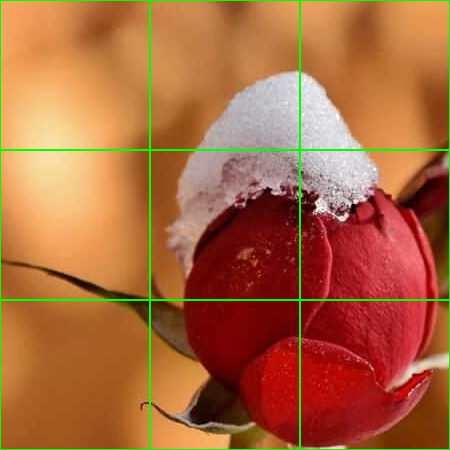

In [ ]:
# Import packages
import cv2
import numpy as np
import os
from google.colab.patches import cv2_imshow

# Read the image
img = cv2.imread("test_cropped.jpg")

# Check if the image was loaded correctly
if img is None:
    raise FileNotFoundError("A imagem 'test_cropped.jpg' não foi encontrada.")

# Make a copy of the image
image_copy = img.copy()

# Get image height and width
imgheight = img.shape[0]
imgwidth = img.shape[1]

print("Altura:", imgheight)
print("Largura:", imgwidth)

# Define the patch size
M = 150
N = 150

# Create folder to save the patches
os.makedirs("saved_patches", exist_ok=True)

# Divide the image into 3x3 square patches
for y in range(0, 450, M):
    for x in range(0, 450, N):

        # Crop the patch
        tiles = image_copy[y:y + M, x:x + N].copy()

        # Define the output filename
        output = f"saved_patches/tile{x}_{y}.jpg"

        # Save the patch
        if not cv2.imwrite(output, tiles):
            raise OSError(f"Could not write {output}")

        # Draw rectangle around the patch
        cv2.rectangle(
            img,
            (x, y),
            (x + N - 1, y + M - 1),
            (0, 255, 0),
            1
        )

# Display the image with the patches marked
cv2_imshow(img)

## Aplicações do recorte de imagens

O recorte de imagens possui diversas aplicações em visão computacional. Uma das principais é a definição de uma **Região de Interesse (ROI — Region of Interest)**, permitindo trabalhar somente com uma determinada área da imagem e ignorar regiões que não são relevantes para a aplicação.

Outra aplicação é a divisão de uma imagem em pequenos pedaços, chamados de **patches**. Essa técnica pode ser utilizada em tarefas como análise de texturas, processamento de imagens grandes, preparação de dados e treinamento de modelos de aprendizado de máquina baseados em patches.

### Região de interesse (ROI)

Uma ROI pode ser obtida utilizando o *slicing* de arrays do NumPy:

```python
roi = img[y:y + height, x:x + width]

Uma aplicação prática do recorte é permitir que o usuário selecione uma imagem e informe a região que deseja extrair.

Em uma aplicação web, por exemplo, seria possível:

1. Fazer o upload de uma imagem;
2. Definir as coordenadas da região de interesse;
3. Realizar o recorte utilizando o OpenCV;
4. Exibir o resultado;
5. Salvar a imagem recortada.

Esse processo pode ser implementado posteriormente utilizando ferramentas como o Streamlit, criando uma interface para facilitar a interação com as operações de processamento de imagens.

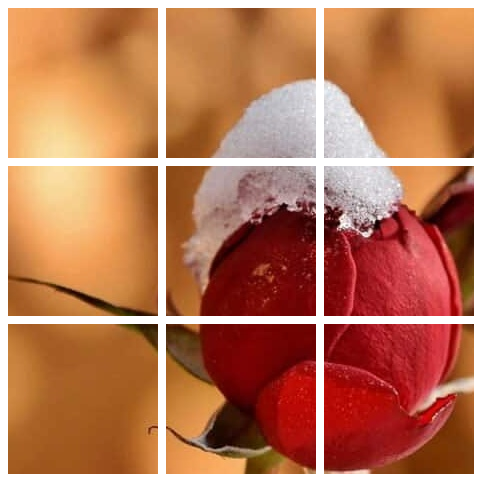

In [ ]:
# Import packages
import cv2
import numpy as np
import os
from google.colab.patches import cv2_imshow

# Read the cropped image
img = cv2.imread("test_cropped.jpg")

# Check if the image was loaded correctly
if img is None:
    raise FileNotFoundError("A imagem 'test_cropped.jpg' não foi encontrada.")

# Crop the image to 450 x 450
img = img[0:450, 0:450]

# Define the patch size
patch_size = 150

# Define the spacing between patches
spacing = 8

# Create folder to save the patches
os.makedirs("saved_patches", exist_ok=True)

# Store the patches
patches = []

# Divide the image into 3x3 patches
for y in range(0, 450, patch_size):

    row = []

    for x in range(0, 450, patch_size):

        # Crop a 150x150 patch
        patch = img[
            y:y + patch_size,
            x:x + patch_size
        ].copy()

        # Save the patch
        filename = f"saved_patches/tile{x}_{y}.jpg"
        cv2.imwrite(filename, patch)

        # Add patch to the current row
        row.append(patch)

    patches.append(row)


# Calculate the size of the final grid
grid_size = (3 * patch_size) + (4 * spacing)

# Create a white background
grid = np.ones(
    (grid_size, grid_size, 3),
    dtype=np.uint8
) * 255


# Place the patches in the grid
for row in range(3):

    for col in range(3):

        y = spacing + row * (patch_size + spacing)
        x = spacing + col * (patch_size + spacing)

        grid[
            y:y + patch_size,
            x:x + patch_size
        ] = patches[row][col]


# Display the final 3x3 grid
cv2_imshow(grid)